In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf
import sys
from module_utils import * 
sys.path.append('../utils')
from Structure3 import *

from data_collection import *
from pathlib import Path

# path to the current notebook
current_file_path = Path().resolve()
# path to the current folder
load_context_functions(current_file_path.parent.name)


True

In [2]:
# reproducibility
seed = 7
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

In [3]:
solver_HF = System1()
solver_LF = System1()

mu_values = np.linspace(1, 5, 10)
params = [(mu,) for mu in mu_values]

(t_HF,y_HF,mu_HF)=solver_HF.generate_dataset(T=10.0, params=np.array(params), h=0.02, fidelity='HF')
solver_HF.save_dataset('dataset_HF.h5')

(t_LF,y_LF,mu_LF)=solver_LF.generate_dataset(T=10.0, params=np.array(params), h=0.05, fidelity='LF')
solver_LF.save_dataset('dataset_LF.h5')


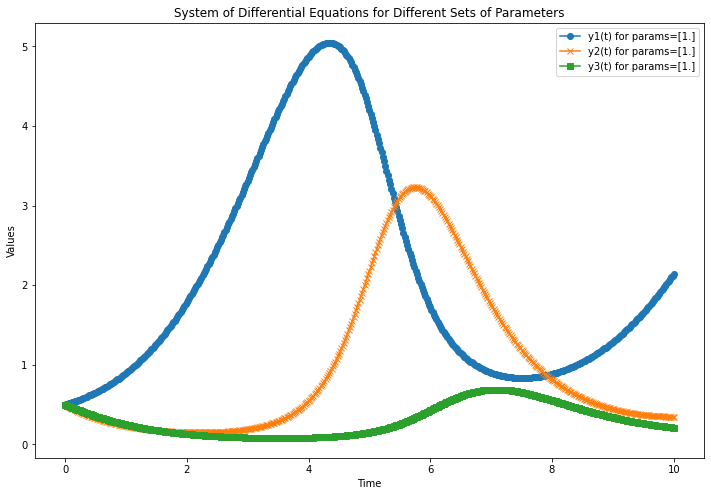

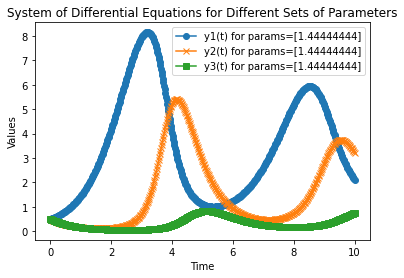

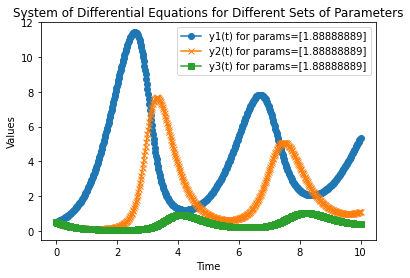

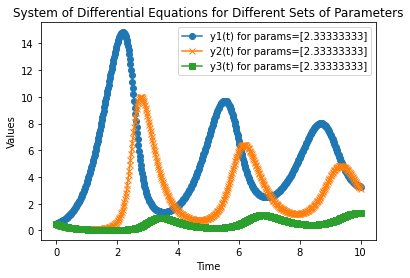

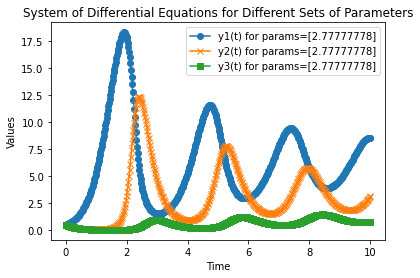

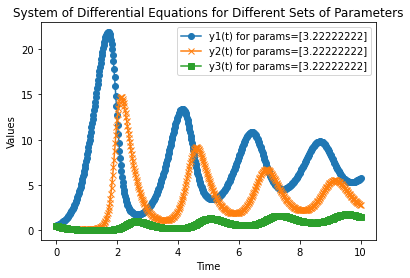

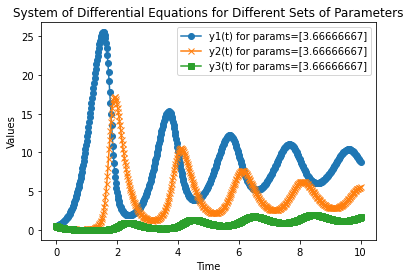

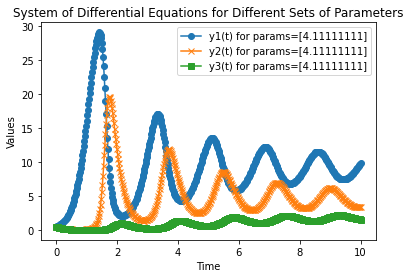

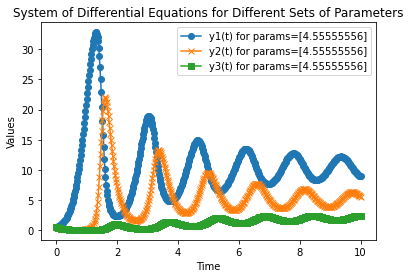

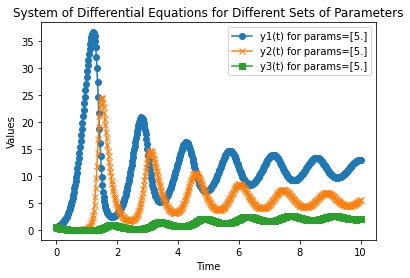

In [4]:
solver_HF.plot_results()

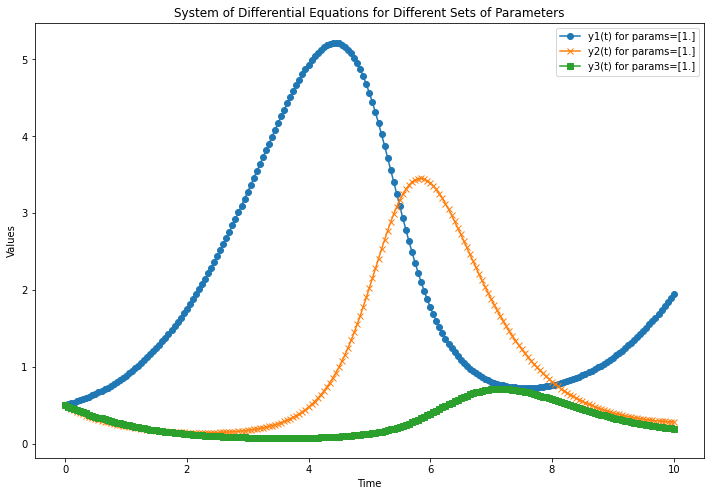

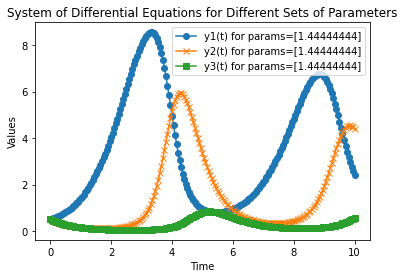

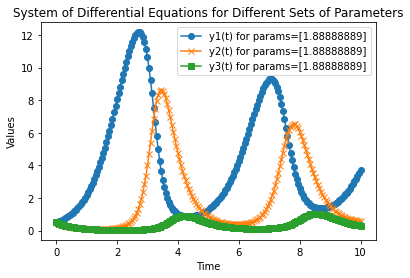

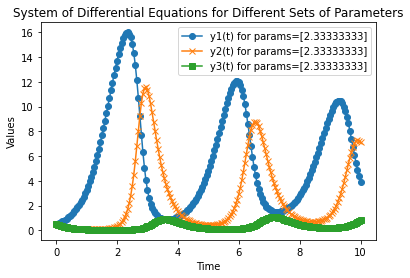

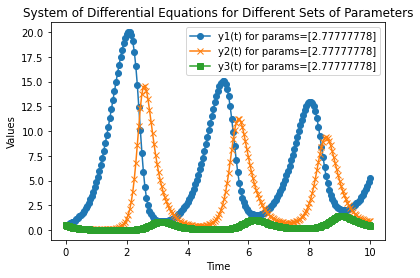

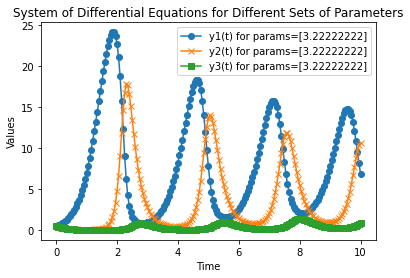

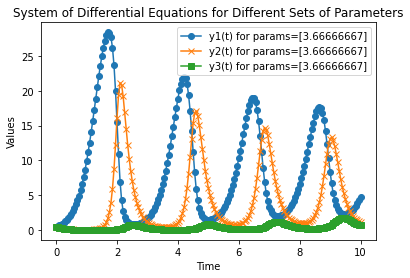

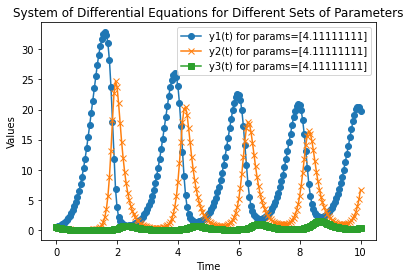

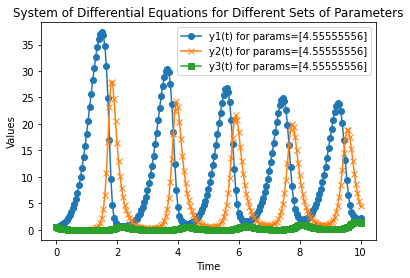

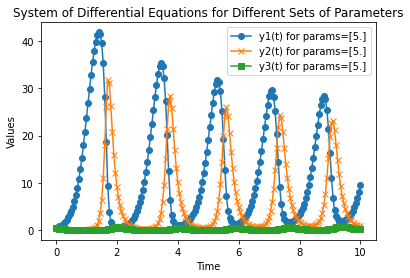

In [5]:
solver_LF.plot_results()

In [6]:
print(t_HF.shape)
print(mu_HF.shape)

x_HF=np.array(np.meshgrid(mu_HF,t_HF)).T.reshape(-1, 2)[:,[1,0]]
x_LF=np.array(np.meshgrid(mu_LF,t_LF)).T.reshape(-1, 2)[:,[1,0]]
print(x_HF)

(501,)
(10, 1)
[[ 0.    1.  ]
 [ 0.02  1.  ]
 [ 0.04  1.  ]
 ...
 [ 9.96  5.  ]
 [ 9.98  5.  ]
 [10.    5.  ]]


In [8]:
print(np.array(np.meshgrid(mu_HF,t_HF)).T.reshape(-1, 2)[:,[1,0]])

[[ 0.    1.  ]
 [ 0.02  1.  ]
 [ 0.04  1.  ]
 ...
 [ 9.96  5.  ]
 [ 9.98  5.  ]
 [10.    5.  ]]


In [ ]:
x_LF

array([[ 1.  ,  0.  ],
       [ 1.  ,  0.05],
       [ 1.  ,  0.1 ],
       ...,
       [ 5.  ,  9.9 ],
       [ 5.  ,  9.95],
       [ 5.  , 10.  ]])

In [ ]:

# file_path = 'dataset_mu_LF.csv'

# # [t, y_values_list[i][j, 0], y_values_list[i][j, 1], a_values[i],b_values[i],c_values[i],d_values[i]]
# data_LF = np.genfromtxt(file_path, delimiter=',', dtype=None)

# file_path = 'dataset_mu_HF.csv'

# data_HF = np.genfromtxt(file_path, delimiter=',', dtype=None)

# model_list=[0]*len(np.unique(data_LF[:,-4]))

In [ ]:
len(y_HF)

10

In [ ]:
y_HF[0]


(501, 3)

In [7]:
y_HF=np.array(y_HF).reshape(-1, 3)
y_LF=np.array(y_LF).reshape(-1, 3)

In [ ]:
a.reshape(-1, 3)

array([[ 0.5       ,  0.5       ,  0.5       ],
       [ 0.50455708,  0.49110162,  0.49352448],
       [ 0.50922863,  0.48240253,  0.48709897],
       ...,
       [12.90365036,  5.39572641,  1.97452557],
       [12.90319825,  5.48926501,  1.98650391],
       [12.88912533,  5.58358671,  2.00037903]])

In [ ]:
x_HF

array([[ 0.        ,  1.        ],
       [ 0.        ,  1.44444444],
       [ 0.        ,  1.88888889],
       ...,
       [10.        ,  4.11111111],
       [10.        ,  4.55555556],
       [10.        ,  5.        ]])

The function training took 2.677398 seconds.


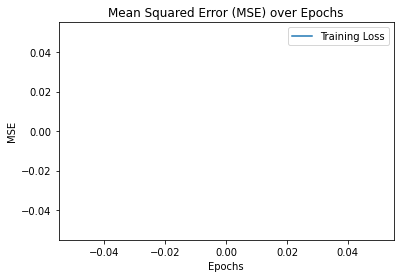

The function training took 8.168439 seconds.


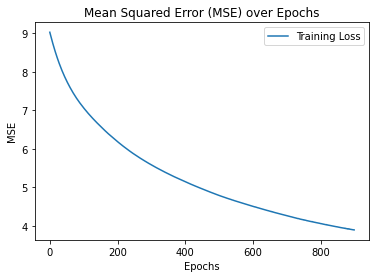

Test MSE: 3.8974936640841404
R^2: 0.7947608726852892


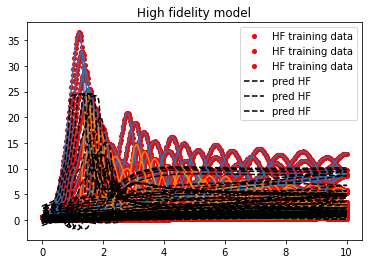

In [8]:
N=[100,1000]
n=[1500,2000]
names = ['LF', 'HF']

# parameters 
bestLF_params = {
    "lr": 0.0255,
    "kernel_init": "glorot_uniform",
    "opt": "Adam",
} 
best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

params_NN=[bestLF_params, best_params]


# collection of the parameters
definition_2steps = {
    "network_type": "2step",
    "names": names,
    "params": params_NN,
    "data_train": [x_LF,x_HF],
    "output_train": [y_LF, y_HF],
    "N": N,
    "n": n,
    "train": True,
    "do_HPO": False,
    "verbose": False
}

final_model = NetworkFactory.build_network(**definition_2steps)

solver_test=System1()
mu_values_test = np.linspace(1, 5, 15)
params_test = [(mu,) for mu in mu_values_test]
(t_test,y_test,mu_test)=solver_test.generate_dataset(T=10.0, params=np.array(params), h=0.005, fidelity='HF')
solver_test.save_dataset('dataset_test.h5')

datatest=np.array(np.meshgrid(mu_test, t_test)).T.reshape(-1, 2)[:,[1,0]]

y_test_pred=final_model.prediction(datatest)

(mse_MF,R_MF)=final_model.performance(datatest,np.array(y_test).reshape(-1,3))


# Plotting data
plt.plot(x_HF[:, 0], y_HF, 'ro', label='HF training data', markersize=4)
plt.plot(datatest[:, 0], np.array(y_test).reshape(-1, 3))
plt.plot(datatest[:, 0], y_test_pred, 'k--', label='pred HF')

# Adding legend and title
plt.legend()
plt.title('High fidelity model')

# Show the plot
plt.show()

In [9]:
x

NameError: name 'x' is not defined

In [ ]:
mean_prior = np.array([2.5])
cov_prior = np.diag([1.])

sigma_noise = [0.25,0.5]
n_data = [50,30]
parameters = np.array([5.])
sigma = np.array([ 4.,2.])
rwmh_scaling = np.array([ 2.,0.5,1.])
rwmh_cov = np.eye(1)
rwmh_adaptive = True
iterations = 300
burnin = 200
n_chains = 2
algo = "MH"

# ricorda che i primi due non vanno bene in qualunque caso

estimateMF, errorMF= run_simulation(x_HF, mean_prior, cov_prior, y_HF, sigma_noise, n_data, parameters, sigma, rwmh_scaling, rwmh_cov, rwmh_adaptive, iterations, burnin, n_chains, final_model,algo)


KeyboardInterrupt: 

In [ ]:
cov_prior = np.diag([1.,1.,1.])


In [12]:
# Define inputs
mean_prior = np.array([7.])
cov_prior = np.diag([1.])
Yhf = y_HF
sd_noise = [0.1,0.05]
N = 300
burn_in = 200
number_chains = 2
algo = "MH"
x_real = np.array([5.])
proposal_sd = [4.,2.]
adapt = True
n_data = [50,30]


module_directory = os.path.abspath(os.path.join('..', 'utils'))

# Add the 'utils' directory containing Structure2.py to the PYTHONPATH
os.environ['PYTHONPATH'] = module_directory
sys.path.append(module_directory)

x_data=  np.linspace(0., 5., n_data[0]).reshape(-1, 1)  # Generate evaluation times
nearest_x, y_obs = process_data(x_HF, x_real, x_data, Yhf) 

# estimates = final_model.inverse_cuqi(
#     mean_prior=mean_prior,
#     x_real=x_real,
#     y_obs=y_obs,
#     N=N,
#     burn_in=burn_in,
#     cov_prior=cov_prior,
#     sd_noise=sd_noise,  
#     adapt=adapt,
#     scale=proposal_sd,
#     proposal_sd=proposal_sd,
#     number_chains=number_chains,
#     algo=algo,
#     x_data=x_data
# )
estimates=run_simulation_cuqi(x_HF,y_HF,
    mean_prior,
    x_real,
    N,
    burn_in,
    cov_prior,
    sd_noise,  
    adapt,
    
    proposal_sd,
    number_chains,
    algo,
    x_data,
    n_data,
    final_model,
    parallel=False
) 

ValueError: operands could not be broadcast together with shapes (50,3) (150,) 

In [ ]:
x_HF.shape

(5010, 2)

In [ ]:
mean=np.mean(x_HF)

In [ ]:
mean

4.0

In [ ]:
# Name of the folder
folder_name = "2_step_models_mu"
folder_path = os.path.join(os.getcwd(), folder_name)

# create the folder
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"Folder '{folder_name}' created.")
else:
    print(f"Folder '{folder_name}' already exists.")
            
test_mse_HF_list = []
test_mse_LF_list = []

r2_HF_list = []
r2_LF_list = []

data_HF_test=np.empty((0,data_HF.shape[1]))
data_HF_train=np.empty((0,data_HF.shape[1]))
data_LF_test=np.empty((0,data_LF.shape[1]))
data_LF_train=np.empty((0,data_LF.shape[1]))

In [ ]:
nlf=200
nhf=150
batch_size=[nlf,nhf]

# number of epochs 
Nepo = [1000,10000]

indexes_LF = np.where(np.diff(data_LF[:,-1]) != 0)[0] + 1
indexes_LF = np.insert(indexes_LF, 0, 0)
indexes_LF = np.append(indexes_LF, len(data_LF))


indexes_HF = np.where(np.diff(data_HF[:,-1]) != 0)[0] + 1
indexes_HF = np.insert(indexes_HF, 0, 0)
indexes_HF = np.append(indexes_HF, len(data_HF))


r2_HF_df = pandas.DataFrame(columns=['mu','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['mu','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['mu','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['mu','MSE'])  # dataframe which stores LF MSE